In [5]:
# Import libraries
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import distance_transform_edt
from affine import Affine

In [2]:
# --
gdf_polg = gpd.read_file('https://github.com/francobarrionuevoenv21/raster_distance_py/raw/refs/heads/main/data_test/areas_urbanas_rep.geojson')
gdf_line = gpd.read_file('https://github.com/francobarrionuevoenv21/raster_distance_py/raw/refs/heads/main/data_test/rutas_prov_rep03.geojson')

In [7]:
VECTOR_PATH = 'https://github.com/francobarrionuevoenv21/raster_distance_py/raw/refs/heads/main/data_test/areas_urbanas_rep.geojson'
PX_M = 10
OUTPUT = 'urb_dist_map'

In [ ]:
def get_hemsph(vector_gdf):
    
    # Convert to EPSG:4326
    vector_4326 = vector_gdf.to_crs('EPSG:4326')
    
    # Extract boundaries coordinates
    minx, miny, maxx, maxy = vector_4326.total_bounds
    
    # Compute mean latitude value
    lat_mean = ((maxy+miny)/2)
    
    # Retur Southern or Northern hemisphere according the latitude
    if lat_mean < 0:
        return 1 # Southen Hemisphere
    else:
        return 0 # Northern Hemisphere
    

def read_reprj_m(vector_path):
    
    # Read vector file
    gdf = gpd.read_file(vector_path)
    
    # Get hemisphere
    hemsph = get_hemsph(gdf)
    
    # Get CRS in UTM (in m) according to hemisphere
    
    crs = None
    
    if hemsph == 1:
        crs = 'EPSG:32720'
    else:
        crs = 'EPSG:32632'
        
    return gdf.to_crs(crs)
        
# --

def get_transform(vector_gdf_reprjm, px_m):
    
    # Define squared pixel
    pxx_m = pxy_m = px_m
    
    # Get reprojected vector boundaries coordinates
    minx, miny, maxx, maxy = vector_gdf_reprjm.total_bounds
    
    # Define transform matrix values
    a = pxx_m # pixel width (x-resolution) — size of a pixel in the x-direction
    b =	0 # row rotation (usually 0 for north-up rasters)
    c =	minx # x-coordinate of the upper-left corner of the upper-left pixel
    d =	0 # column rotation (usually 0 for north-up rasters)
    e =	-pxy_m # pixel height (y-resolution) — usually negative, since y decreases as row index increases (raster origin is top-left, but y increases upward in most CRS)
    f =	maxy # y-coordinate of the upper-left corner of the upper-left pixel

    return Affine(a, b, c, d, e, f)

def get_profile(shape, transform):
    
    return {'driver': 'GTiff',
        'height': shape[0],
        'width': shape[1],
        'count': 1,
        'dtype': 'float32',
        'nodata': -9999,
        'crs': crs,
        'transform': transform}

def vector_to_raster(vector_gdf_reprjm, px_m, target, no_target):
    
    # Get transform according the vector
    transform = get_transform(vector_gdf_reprjm, px_m)
    
    # Compute output raster shape
    minx, miny, maxx, maxy = vector_gdf_reprjm.total_bounds
    shape = (int((maxy - miny)//pxy_m), int((maxx - minx)//pxx_m))
    
    # Convert vector to raster
    vector_array = rasterize(
        [(shape, label) for shape, label in zip(vector_gdf_reprjm['geometry'], 
                                                np.ones(vector_gdf_reprjm.shape[0], dtype=np.int16)*target)],
        out_shape=shape,
        transform=transform,
        fill=no_target,
        all_touched=True,
        dtype=rasterio.int16)
    
    return vector_array, get_profile(shape, transform)

def array_distance(vector_array, px_m, no_target):
    
    # Get array of distances
    # distance_transform_edt computes distance to nearest 'no_target' from any 'target'. The method takes 0 as no-target by default
    dist_array_px = distance_transform_edt(vector_array == no_target).astype(np.float32) # distance in pixels
    dist_array_m = dist_px * px_m
    
    return dist_array_m

def export_raster(dist_array_m, profile, file_output):
    
    # Export distance array as tif file with rasterio
    with rasterio.open(f'{file_output}.tif', 'w', **profile) as dst:
        dst.write(dist_array_m, 1)
    

#def vector_to_distance(vector_gdf_reprjm, px_m, file_output = 'output', target = 1, no_target = 0):
def vector_to_distance(vector_path, px_m, file_output = 'output', target = 1, no_target = 0):
    
    # Read the vector and reproject to UTM
    vector_gdf_reprjm = read_reprj_m(vector_path)
    
    # Get vector array and profile
    vector_array, profile = vector_to_raster(vector_gdf_reprjm, px_m, target, no_target)
    
    # Get distance array in meters (m)
    dist_array_m = array_distance(vector_array, px_m, no_target)
    
    # Export distance raster
    export_raster(dist_array_m, profile, file_output)
    
    return dist_array_m
    
    

In [81]:
# --
utm_sh = 'EPSG:32720'
utm_nh = 'EPSG:32632'

# --
crs = utm_sh

In [82]:
gdf = gdf_line.to_crs(crs).dissolve()

In [64]:
gdf.head()

,geometry,gid,rtn,typ,rst,hct,fdc,sag
0,"MULTILINESTRING ((355985.647 6468113.855, 3559...",6674,s430,40,1,2,IDECOR,IGN


<Axes: >

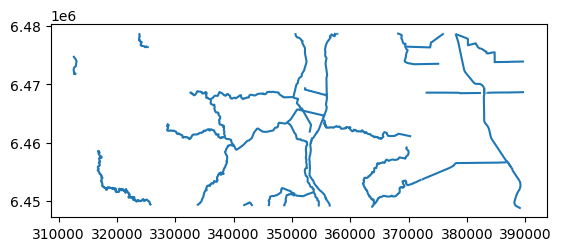

In [65]:
gdf.plot()

In [66]:
# --
minx, miny, maxx, maxy = gdf.total_bounds

In [67]:
# --
pxx_m = pxy_m = 10

# --
shape_x = int((maxx - minx)//pxx_m)
shape_y = int((maxy - miny)//pxy_m)

# --
label_column = 'gid'

# --
no_target = 0
target = 1

In [68]:
from affine import Affine

# --
a = pxx_m # pixel width (x-resolution) — size of a pixel in the x-direction
b =	0 # row rotation (usually 0 for north-up rasters)
c =	minx # x-coordinate of the upper-left corner of the upper-left pixel
d =	0 # column rotation (usually 0 for north-up rasters)
e =	-pxy_m # pixel height (y-resolution) — usually negative, since y decreases as row index increases (raster origin is top-left, but y increases upward in most CRS)
f =	maxy # y-coordinate of the upper-left corner of the upper-left pixel

transform = Affine(a, b, c, d, e, f)

In [ ]:
# Convert vector to raster
shape = (shape_y, shape_x)#image_ref.shape
transform = transform
rasterize_array = rasterize(
    [(shape, label) for shape, label in zip(gdf['geometry'], np.ones(gdf.shape[0], dtype= np.int16)*target)],
    out_shape=shape,
    transform=transform,
    fill=no_target,
    all_touched=True,
    dtype=rasterio.int16)

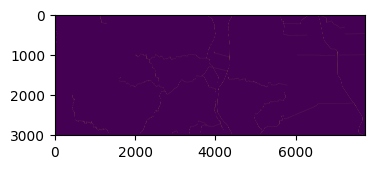

In [70]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(rasterize_array)

In [78]:
# distance_transform_edt computes distance to nearest 0 by default,
# so invert: treat urban (1) as the "target" -> compute distance FROM non-urban TO urban
dist_px = distance_transform_edt(rasterize_array == 0).astype(np.float32) # distance in pixels, to nearest urban cell

# convert pixel distance to real-world units (assuming square pixels)
#pixel_size = transform[0]  # or transform.a
dist_geo = dist_px * pxx_m

'''profile.update(dtype=rasterio.float32)
with rasterio.open("output.tif", "w", **profile) as dst:
    dst.write(dist_geo.astype(np.float32), 1)'''

'profile.update(dtype=rasterio.float32)\nwith rasterio.open("output.tif", "w", **profile) as dst:\n    dst.write(dist_geo.astype(np.float32), 1)'

In [84]:
# --
profile = {
    'driver': 'GTiff',
    'height': shape[0],
    'width': shape[1],
    'count': 1,
    'dtype': 'float32',
    'nodata': -9999,
    'crs': crs,
    'transform': transform,
}

# --
with rasterio.open('output.tif', 'w', **profile) as dst:
    dst.write(dist_geo, 1)

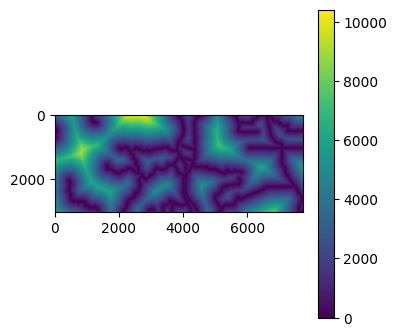

In [74]:
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(dist_geo)
fig.colorbar(im)